In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("PysparkProject") \
    .getOrCreate()

In [2]:
df = spark.read.csv("C:/Users/kyoan/Documents/Python_Sorbonne/Pyspark/Online_Retail_CSV.csv", header=True, inferSchema=True, sep=";")

In [3]:
df.show()

+---------+---------+--------------------+--------+----------------+---------+----------+--------------+
|InvoiceNo|StockCode|         Description|Quantity|     InvoiceDate|UnitPrice|CustomerID|       Country|
+---------+---------+--------------------+--------+----------------+---------+----------+--------------+
|   536365|   85123A|WHITE HANGING HEA...|       6|01/12/2010 08:26|     2,55|     17850|United Kingdom|
|   536365|    71053| WHITE METAL LANTERN|       6|01/12/2010 08:26|     3,39|     17850|United Kingdom|
|   536365|   84406B|CREAM CUPID HEART...|       8|01/12/2010 08:26|     2,75|     17850|United Kingdom|
|   536365|   84029G|KNITTED UNION FLA...|       6|01/12/2010 08:26|     3,39|     17850|United Kingdom|
|   536365|   84029E|RED WOOLLY HOTTIE...|       6|01/12/2010 08:26|     3,39|     17850|United Kingdom|
|   536365|    22752|SET 7 BABUSHKA NE...|       2|01/12/2010 08:26|     7,65|     17850|United Kingdom|
|   536365|    21730|GLASS STAR FROSTE...|       6|01/1

In [4]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

# =========================
# (A) Optionnel : si df_clean n'existe pas encore
# =========================
# df_clean : DF transactionnel nettoyé (CustomerID non null, retours et annulations retirés, types corrects)
# Si tu as déjà df_clean et rfm, tu peux ignorer cette partie.

df_clean = (df
    .filter(F.col("CustomerID").isNotNull())
    .withColumn("Quantity", F.col("Quantity").cast("int"))
    .withColumn("UnitPrice", F.regexp_replace("UnitPrice", ",", ".").cast("double"))
    .withColumn("InvoiceDate", F.to_timestamp("InvoiceDate", "dd/MM/yyyy HH:mm"))
    .withColumn("Total", F.col("Quantity") * F.col("UnitPrice"))
    .filter(~F.col("InvoiceNo").startswith("C"))   # annulations
    .filter(F.col("Quantity") > 0)                 # retours
    .filter(F.col("UnitPrice") > 0)
)

# =========================
# (B) Construction RFM au niveau client
# =========================
ref_date = df_clean.agg(F.max("InvoiceDate").alias("maxd")).collect()[0]["maxd"]

rfm = (df_clean
    .groupBy("CustomerID")
    .agg(
        F.datediff(F.lit(ref_date), F.max("InvoiceDate")).alias("recency"),
        F.countDistinct("InvoiceNo").alias("frequency"),
        F.sum("Total").alias("monetary"),
        F.countDistinct("StockCode").alias("n_distinct_products"),
        F.avg("Total").alias("avg_basket")
    )
)

# =========================
# (C) Feature "main_country" : pays le plus fréquent par client
# =========================
w = Window.partitionBy("CustomerID").orderBy(F.desc("cnt"))
country_by_customer = (df_clean
    .groupBy("CustomerID", "Country").count()
    .withColumnRenamed("count", "cnt")
    .withColumn("rn", F.row_number().over(w))
    .filter(F.col("rn") == 1)
    .select("CustomerID", F.col("Country").alias("main_country"))
)

data_sup = rfm.join(country_by_customer, on="CustomerID", how="left")

# =========================
# (D) Création du label "gros dépensier"
# =========================
THRESHOLD = 500.0
data_sup = data_sup.withColumn("label", (F.col("monetary") > THRESHOLD).cast("int"))

# Vérification du déséquilibre de classes
data_sup.groupBy("label").count().show()

+-----+-----+
|label|count|
+-----+-----+
|    1| 2576|
|    0| 1762|
+-----+-----+



In [6]:
# Split : 
train_df, test_df = data_sup.randomSplit([0.7, 0.3], seed=42)

In [7]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler

# Encodage Country
idx = StringIndexer(inputCol="main_country", outputCol="country_idx", handleInvalid="keep")
ohe = OneHotEncoder(inputCols=["country_idx"], outputCols=["country_ohe"])

# Assemblage des variables numériques + one-hot
assembler = VectorAssembler(
    inputCols=["recency", "frequency", "avg_basket", "n_distinct_products", "country_ohe"],
    outputCol="features"
)

In [8]:
from pyspark.ml.classification import RandomForestClassifier

rf = RandomForestClassifier(
    labelCol="label",
    featuresCol="features",
    numTrees=200,
    maxDepth=8,
    seed=42
)

pipeline = Pipeline(stages=[idx, ohe, assembler, rf])

model = pipeline.fit(train_df)
pred = model.transform(test_df)

pred.select("CustomerID", "label", "prediction", "probability").show(5, truncate=False)

+----------+-----+----------+----------------------------------------+
|CustomerID|label|prediction|probability                             |
+----------+-----+----------+----------------------------------------+
|12348     |1    |1.0       |[0.19895241629361182,0.8010475837063882]|
|12353     |0    |0.0       |[0.8361715855475089,0.16382841445249105]|
|12355     |0    |0.0       |[0.7449573405649427,0.2550426594350573] |
|12356     |1    |1.0       |[0.05312085602757496,0.9468791439724251]|
|12360     |1    |1.0       |[0.04419332284557254,0.9558066771544275]|
+----------+-----+----------+----------------------------------------+
only showing top 5 rows


In [9]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator
from pyspark.sql import functions as F

# Accuracy & F1
e_acc = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
e_f1  = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")

acc = e_acc.evaluate(pred)
f1  = e_f1.evaluate(pred)

# AUC
e_auc = BinaryClassificationEvaluator(labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderROC")
auc = e_auc.evaluate(pred)

print(f"Accuracy = {acc:.4f}")
print(f"F1-score  = {f1:.4f}")
print(f"AUC       = {auc:.4f}")

# Matrice de confusion (counts)
cm = (pred
    .groupBy("label", "prediction")
    .count()
    .orderBy("label", "prediction")
)
cm.show()

Accuracy = 0.9207
F1-score  = 0.9207
AUC       = 0.9797
+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|    0|       0.0|  473|
|    0|       1.0|   52|
|    1|       0.0|   46|
|    1|       1.0|  665|
+-----+----------+-----+



In [10]:
from pyspark.ml.tuning import ParamGridBuilder, TrainValidationSplit

paramGrid = (ParamGridBuilder()
    .addGrid(rf.numTrees, [100, 200])
    .addGrid(rf.maxDepth, [6, 8, 10])
    .build()
)

tvs = TrainValidationSplit(
    estimator=pipeline,
    estimatorParamMaps=paramGrid,
    evaluator=e_auc,
    trainRatio=0.8,
    seed=42
)

tvs_model = tvs.fit(train_df)
pred_tuned = tvs_model.transform(test_df)

auc_tuned = e_auc.evaluate(pred_tuned)
print(f"AUC (tuned) = {auc_tuned:.4f}")

AUC (tuned) = 0.9809


In [11]:
# 5) 

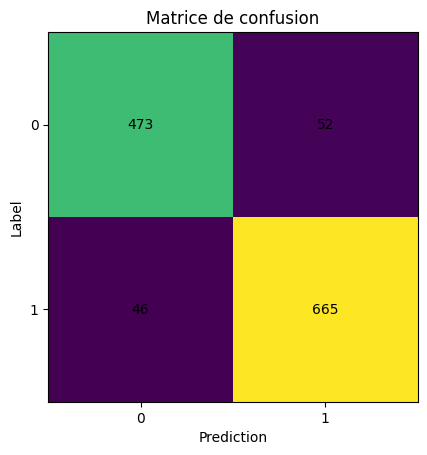

In [25]:
import matplotlib.pyplot as plt

cm = pred.groupBy("label","prediction").count().toPandas()
cm_pivot = cm.pivot(index="label", columns="prediction", values="count").fillna(0)

plt.figure()
plt.imshow(cm_pivot.values)
plt.title("Matrice de confusion")
plt.xlabel("Prediction")
plt.ylabel("Label")

for i in range(cm_pivot.shape[0]):
    for j in range(cm_pivot.shape[1]):
        plt.text(j, i, int(cm_pivot.values[i, j]), ha="center", va="center")

plt.xticks([0,1])
plt.yticks([0,1])
plt.show()